In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## What is the best age to grant a loan with minimal risk?

## Reading the raw data

In [91]:
df = pd.read_csv("../Data/credit_risk_dataset.csv", header=0)
df

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26


In [92]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')

In [93]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [94]:
df["loan_amnt"].min()
df["loan_amnt"].max()

35000

Text(0, 0.5, 'Frequency')

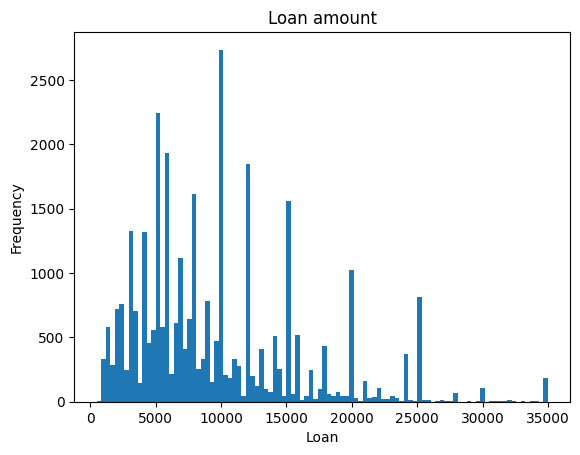

In [95]:
df["loan_amnt"].plot(kind="hist", bins = 100)
plt.title("Loan amount")
plt.xlabel("Loan")
plt.ylabel("Frequency")

Text(0, 0.5, 'Frequency')

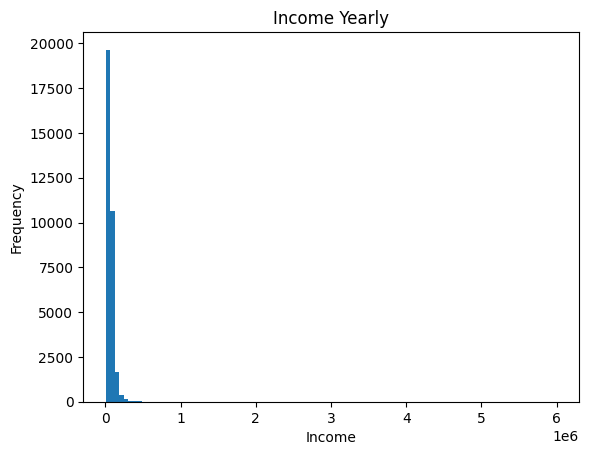

In [96]:
df["person_income"].plot(kind="hist", bins = 100)
plt.title("Income Yearly")
plt.xlabel("Income")
plt.ylabel("Frequency")

In [97]:
print(df["person_income"].min())
print(df["person_income"].max())

4000
6000000


In [98]:
df_filttered = df[df["person_income"]<500000]

Text(0, 0.5, 'Frequency')

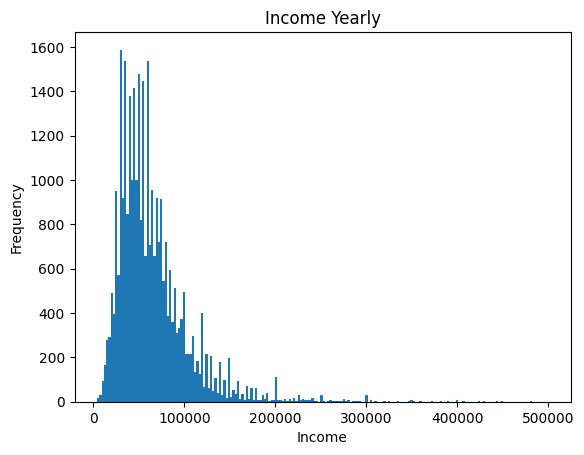

In [99]:
df_filttered["person_income"].plot(kind="hist", bins = 200)
plt.title("Income Yearly")
plt.xlabel("Income")
plt.ylabel("Frequency")

Text(0, 0.5, 'Frequency')

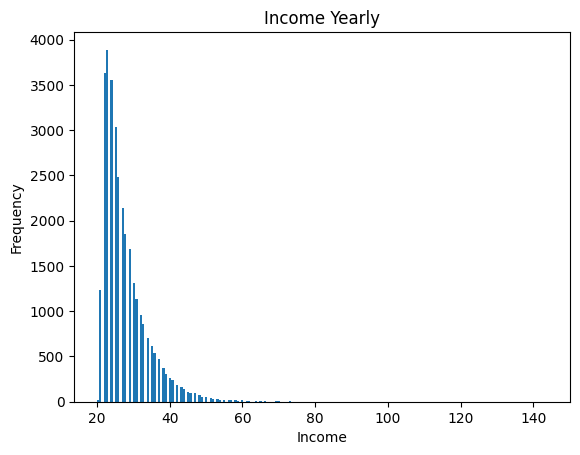

In [100]:
df_filttered["person_age"].plot(kind="hist", bins = 200)
plt.title("Income Yearly")
plt.xlabel("Income")
plt.ylabel("Frequency")

In [101]:
print(df["person_age"].min())
print(df["person_age"].max())

20
144


Text(0, 0.5, 'Frequency')

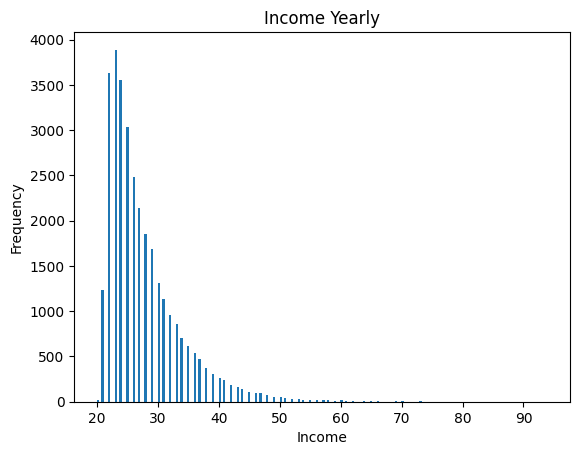

In [102]:
df_filttered = df_filttered[df_filttered["person_age"]<120]
df_filttered["person_age"].plot(kind="hist", bins = 200)
plt.title("Income Yearly")
plt.xlabel("Income")
plt.ylabel("Frequency")

In [103]:
print(df["person_emp_length"].min())
print(df["person_emp_length"].max())

0.0
123.0


I will use work experience of 40 because, in our data, people start working at age 20. Since people retire at age 66, the maximum work experience would be 40.

Text(0, 0.5, 'Frequency')

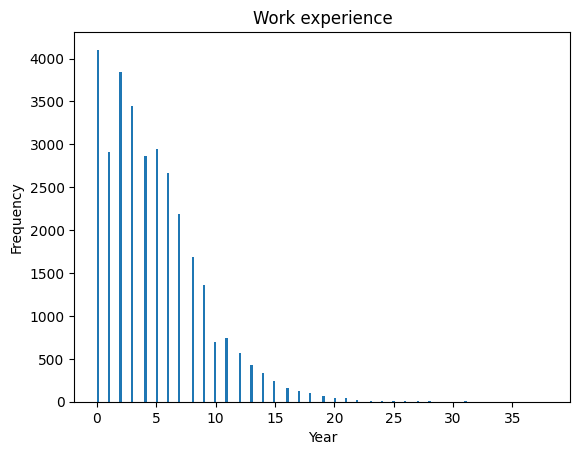

In [104]:
df_filttered = df_filttered[df_filttered["person_emp_length"]<40]
df_filttered["person_emp_length"].plot(kind="hist", bins = 200)
plt.title("Work experience")
plt.xlabel("Year")
plt.ylabel("Frequency")

#### Let’s test the basic logic of how much work experience people under 25 have.

Text(0, 0.5, 'Frequency')

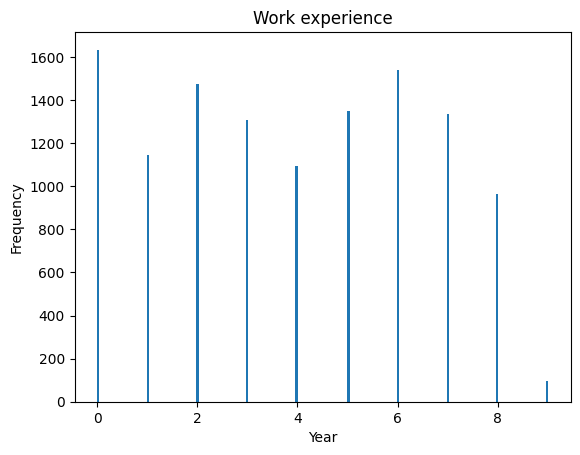

In [109]:
df_filttered_test= df_filttered[df_filttered["person_age"]<25]
df_filttered_test["person_emp_length"].plot(kind="hist", bins = 200)
plt.title("Work experience")
plt.xlabel("Year")
plt.ylabel("Frequency")